In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [12]:
df = pd.read_csv("BBDD_100K/ratings.csv")

indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
escasez=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')

def normalizar_datos(matriz_escasez):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_escasez.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy

matriz_normalizada = normalizar_datos(escasez)
matriz_normalizada.head(20)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.458937,0.000000,-0.458937,0.000000,0.000000,-0.458937,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.371391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.596225,1.773677,-0.581226,1.773677,0.596225,0.596225,-0.581226,0.0,-0.581226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.958138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.442374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.636784,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Determinar la mejor K

Método del Codo: Evalúa la inercia (suma de las distancias cuadradas de las muestras a su centroide más cercano).

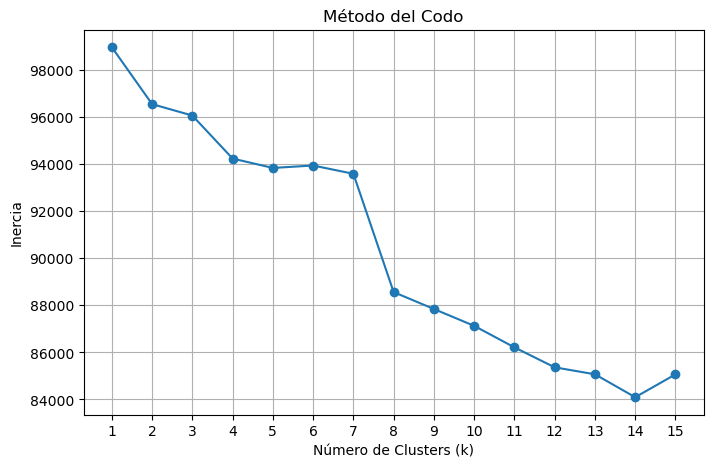

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def metodo_del_codo(matriz, max_k=15):
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(matriz)
        inercia.append(kmeans.inertia_)
    
    # Graficar la inercia para ver el "codo"
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.title('Método del Codo')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inercia')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

# Ejecuta el método del codo con la matriz normalizada
metodo_del_codo(matriz_normalizada)


Observando la curva, parece que el "codo" ocurre alrededor de k = 8, donde la disminución de la inercia se vuelve menos pronunciada. Esto sugiere que 8 clústeres podría ser un valor razonable.

Silhouette Score: Mide qué tan cerca están los puntos de su clúster en comparación con otros clústeres.\
Es otra forma de mirar la k óptima, pero en este caso estamos teniendo en cuenta las distáncias, mientras que el método del Codo no se tienen en cuenta las distancias

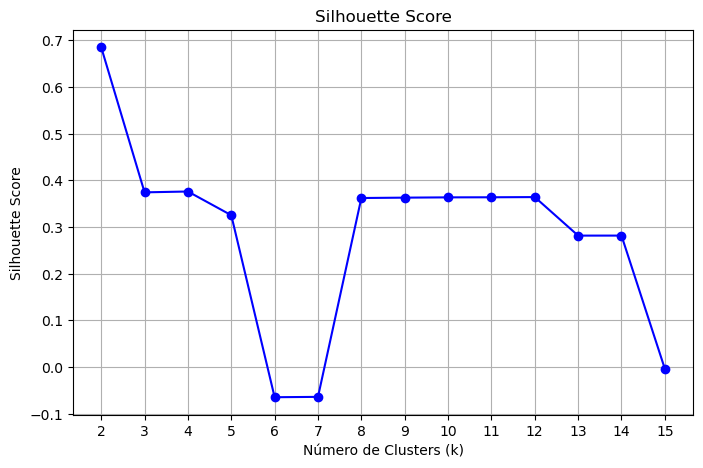

In [19]:
from sklearn.metrics import silhouette_score

def calcular_silhouette_score(matriz, min_k=2, max_k=15):
    """Calcula y guarda el Silhouette Score para diferentes valores de k."""
    silhouette_scores = []
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(matriz)
        score = silhouette_score(matriz, labels)
        silhouette_scores.append(score)
    
    # Graficar el Silhouette Score
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), silhouette_scores, marker='o', color='blue')
    plt.title('Silhouette Score')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(min_k, max_k + 1))
    plt.grid(True)
    plt.show()

# Ejecución: guarda la lista de Silhouette Scores
calcular_silhouette_score(matriz_normalizada)


k=2 tiene el Silhouette Score más alto (0.6850), lo cual es típico porque agrupar todo en 2 clústeres maximiza la cohesión interna.

Sin embargo, después de k=2, el puntaje es más estable y ligeramente mejor en k=12 (0.3641), aunque las diferencias en los valores para k=8 a 12 son mínimas.

La elección entre k=2 (alta separación con menor granularidad) y k=12 (balance razonable) dependerá del nivel de detalle que se busque en las recomendaciones

Puesto que Tanto el método del codo como el de Silhouette coinden ambos en que K=8 es un buen candidato, `nos quedaremos con 8 clusters.`

## Implementar Kmeans para 1 usuario

In [ ]:
def peliculas_del_usuario(usuario, matriz_normalizada):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_normalizada.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales


In [25]:
def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=1, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango y redondeo
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating)
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

In [36]:
from sklearn.cluster import KMeans

def predecir_y_comparar(usuario, matriz_normalizada, matriz_original, k=8):
    """
    Ejecuta KMeans, predice las valoraciones para las películas ya valoradas por un usuario
    y las compara con las valoraciones originales.

    Args:
        usuario (int): ID del usuario.
        matriz_escasez (pd.DataFrame): Matriz normalizada con valoraciones.
        matriz_original (pd.DataFrame): Matriz original de valoraciones.
        k (int): Número de clústeres para KMeans.

    Returns:
        pd.DataFrame: Comparación entre valoraciones originales y predicciones reescaladas.
    """
    
    # Ejecutar KMeans y asignar clústeres
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(matriz_normalizada)
    resultados_clusters = pd.DataFrame({'userId': matriz_normalizada.index, 'Cluster': labels}).set_index('userId')
    
    # Obtener las películas valoradas por el usuario y sus valoraciones originales
    lista_peliculas, valoraciones_originales = peliculas_del_usuario(usuario, matriz_original)
    
    # Obtener el clúster del usuario
    cluster_usuario = resultados_clusters.loc[usuario, 'Cluster']
    
    # Filtrar los usuarios en el mismo clúster
    usuarios_mismo_cluster = resultados_clusters[resultados_clusters['Cluster'] == cluster_usuario].index.tolist()
    
    # Crear una submatriz con los usuarios del mismo clúster
    submatriz_cluster = matriz_original.loc[usuarios_mismo_cluster, lista_peliculas]
    
    # Calcular la media de las valoraciones para cada película en este clúster (predicciones normalizadas)
    predicciones_normalizadas = submatriz_cluster.mean(axis=0).values.tolist()
    
    # Reescalar las predicciones normalizadas
    predicciones_reescaladas = [
        reescalar_prediccion(prediccion, usuario, matriz_original)
        for prediccion in predicciones_normalizadas
    ]
    
    # Crear un DataFrame de comparación
    comparacion = pd.DataFrame({
        'Película': lista_peliculas,
        'Valoración Original': valoraciones_originales,
        'Predicción (Reescalada)': predicciones_reescaladas
    })
    
    return comparacion

# Uso de la función
usuario_id = 3  # Cambia este valor según el usuario que quieras analizar
comparacion_resultados = predecir_y_comparar(
    usuario=usuario_id, 
    matriz_normalizada=matriz_normalizada, 
    matriz_original=escasez, 
    k=8
)

# Mostrar resultados
print(comparacion_resultados.head(10))


   Película  Valoración Original  Predicción (Reescalada)
0        21                  3.0                      5.0
1        32                  2.0                      5.0
2        45                  3.0                      5.0
3        47                  2.0                      5.0
4        52                  3.0                      5.0
5        58                  3.0                      5.0
6       106                  4.0                      5.0
7       125                  5.0                      5.0
8       126                  1.0                      5.0
9       162                  5.0                      5.0


In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


def normalizar_datos(matriz_escasez):
    """Función personalizada de normalización."""
    matriz_escasez_copy = matriz_escasez.copy()
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    for user_id in matriz_escasez_copy.index:
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    return matriz_escasez_copy.fillna(0)

def predecir_y_comparar_ponderado_ajustado(usuario, matriz_escasez, matriz_original, k=8, umbral_similitud=0.1):
    """Predice valoraciones ajustando ponderación según similitud y compara con originales."""
    
    # Normalizar datos
    matriz_normalizada = normalizar_datos(matriz_escasez)
    
    # Ejecutar KMeans y asignar clústeres
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(matriz_normalizada)
    resultados_clusters = pd.DataFrame({'userId': matriz_normalizada.index, 'Cluster': labels}).set_index('userId')
    
    # Obtener el clúster del usuario
    cluster_usuario = resultados_clusters.loc[usuario, 'Cluster']
    
    # Usuarios del mismo clúster
    usuarios_mismo_cluster = resultados_clusters[resultados_clusters['Cluster'] == cluster_usuario].index.tolist()
    
    # Obtener películas valoradas por el usuario
    peliculas_valoradas, valoraciones_originales = peliculas_del_usuario(usuario, matriz_escasez)
    
    # Submatriz del clúster
    submatriz_cluster = matriz_original.loc[usuarios_mismo_cluster, peliculas_valoradas].fillna(0)
    
    # Similitudes coseno
    similitud_usuarios = cosine_similarity(
        matriz_normalizada.loc[[usuario]], 
        matriz_normalizada.loc[usuarios_mismo_cluster]
    ).flatten()
    
    # Aplicar umbral de similitud
    similitud_usuarios = np.where(similitud_usuarios > umbral_similitud, similitud_usuarios, 0)
    
    # Recalcular ponderaciones después del umbral
    similitud_usuarios = similitud_usuarios / similitud_usuarios.sum()  # Redistribuir pesos
    
    # Predicciones ponderadas ajustadas
    predicciones_ponderadas = []
    for pelicula in peliculas_valoradas:
        valoraciones_clust = submatriz_cluster[pelicula].values
        prediccion = np.dot(similitud_usuarios, valoraciones_clust)
        predicciones_ponderadas.append(prediccion)
    
    # Reescalar predicciones
    predicciones_reescaladas = [
        reescalar_prediccion(prediccion, usuario, matriz_original)
        for prediccion in predicciones_ponderadas
    ]
    
    # Comparar
    comparacion = pd.DataFrame({
        'Película': peliculas_valoradas,
        'Valoración Original': valoraciones_originales,
        'Predicción (Reescalada)': predicciones_reescaladas,
        'Predicción Ponderada Ajustada': predicciones_ponderadas
    })
    
    return comparacion

# Ejecutar con el usuario 0
usuario_id = 6
resultados_ajustados = predecir_y_comparar_ponderado_ajustado(
    usuario=usuario_id,
    matriz_escasez=escasez,
    matriz_original=escasez,
    k=8,
    umbral_similitud=0.1
)

print(resultados_ajustados.head(10))



   Película  Valoración Original  Predicción (Reescalada)  \
0         1                  4.5                     4.66   
1        50                  4.5                     4.23   
2        58                  3.0                     3.56   
3       150                  4.5                     5.00   
4       165                  4.0                     5.00   
5       260                  5.0                     3.67   
6       356                  5.0                     5.00   
7       380                  3.0                     5.00   
8       466                  5.0                     4.08   
9       480                  5.0                     5.00   

   Predicción Ponderada Ajustada  
0                       1.365666  
1                       0.861893  
2                       0.078056  
3                       3.629864  
4                       2.962688  
5                       0.204447  
6                       3.854510  
7                       3.477433  
8            